# **Diplomado IA: Deep Learning 1 - Parte 1**. <br> Práctico 11: Redes Recurrentes
---
---

**Profesores:**
- Alain Raymond
- Carlos Aspillaga


El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:**

El siguiente práctico contendrá 1 o más actividades a realizar. Algunas actividades corresponderán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.

---
**IMPORTANTE:** habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0

# Detección de nacionalidad a partir de apellidos utilizando RNNs a nivel de caracteres

Parcialmente basado en:

https://colah.github.io/posts/2015-08-Understanding-LSTMs

https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/

https://towardsdatascience.com/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66

https://pytorch.org/tutorials/beginner/former_torchies/nn_tutorial.html#example-2-recurrent-net

https://colah.github.io/posts/2015-08-Understanding-LSTMs

https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html

https://github.com/donnemartin/data-science-ipython-notebooks/blob/master/deep-learning/keras-tutorial/3.2%20RNN%20and%20LSTM.ipynb

http://juditacs.github.io/2018/12/27/masked-attention.html

Construiremos y entrenaremos Redes Neuronales Recurrentes (RNNs) básicas a nivel de caracteres para clasificar palabras. Intencionalmente este laboratorio no utiliza muchas de las funciones de conveniencia de `torchtext`, para permitir observar la operatoria a bajo nivel.

Una RNN a nivel de caracteres lee palabras como una serie de caracteres, emitiendo una predicción y un "estado oculto" en cada paso, alimentando su estado oculto previo en cada siguiente paso. Tomamos la predicción final proyectada linealmente como la salida, para indicar a qué clase pertenece la palabra.

Específicamente, entrenaremos en unos pocos miles de nombres de 18 idiomas de origen, y prediremos a qué idioma pertenece un nombre basándonos en la ortografía.


## Los Datos

Primero vamos a descargar y descomprimir los datos

In [ ]:
%matplotlib inline

In [ ]:
!wget https://download.pytorch.org/tutorial/data.zip
!unzip data.zip

--2025-12-19 03:31:23--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 13.35.185.6, 13.35.185.45, 13.35.185.7, ...
Connecting to download.pytorch.org (download.pytorch.org)|13.35.185.6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]   2.75M  --.-KB/s    in 0.08s   

2025-12-19 03:31:24 (33.8 MB/s) - ‘data.zip’ saved [2882130/2882130]

Archive:  data.zip
   creating: data/
  inflating: data/eng-fra.txt        
   creating: data/names/
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: data/names/Italian.t

Dentro del directorio ``data/names`` existen 18 archivos de texto con nombre ``[Language].txt``. Cada archivo contiene una serie de nombres, un nombre por línea, en su mayoría romanizados (pero aún necesitamos convertir de Unicode a ASCII).

Luego de ejecutar la siguiente celda, terminaremos con un diccionario de listas de nombres por idioma,
``{language: [names ...]}``.

In [ ]:
from io import open
import glob
import os
import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

def findFiles(path):
    return glob.glob(path)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    # example: this code converts 'Ślusàrski' into 'Slusarski
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []
for filename in findFiles('data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

### **📚 Explicación del Código - Preparación de Datos**

Este código prepara los datos de apellidos para entrenar la RNN.

**¿Qué hace cada función?**

**1. `unicodeToAscii(s)`:**
- Convierte caracteres Unicode a ASCII
- Ejemplo: `'Ślusàrski'` → `'Slusarski'`
- Necesario porque el modelo solo entiende caracteres ASCII básicos

**2. `readLines(filename)`:**
- Lee un archivo de texto
- Convierte cada línea (apellido) a ASCII
- Retorna lista de apellidos procesados

**3. `findFiles(path)`:**
- Busca todos los archivos `.txt` en el directorio `data/names/`
- Cada archivo contiene apellidos de un idioma

**Estructura de datos resultante:**

```python
all_letters = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ .,;'"
n_letters = 57  # Total de caracteres posibles

category_lines = {
    'French': ['Moreau', 'Bernard', 'Dubois', ...],
    'English': ['Smith', 'Johnson', 'Williams', ...],
    'Spanish': ['García', 'Rodriguez', 'Martinez', ...],
    ...
}

all_categories = ['Arabic', 'Chinese', 'Czech', 'Dutch', 'English',
                  'French', 'German', 'Greek', 'Irish', 'Italian',
                  'Japanese', 'Korean', 'Polish', 'Portuguese',
                  'Russian', 'Scottish', 'Spanish', 'Vietnamese']
n_categories = 18  # Total de idiomas
```

**¿Por qué normalizar a ASCII?**
- Las redes neuronales necesitan entradas numéricas
- Cada carácter se convertirá en un vector one-hot
- Mantener solo ASCII simplifica el vocabulario

Ahora tenemos ``category_lines``, un diccionario que asigna cada categoría (idioma) a una lista de líneas (nombres). También llevamos un registro de ``all_categories`` (simplemente una lista de idiomas) y ``n_categories`` para referencia posterior.




In [ ]:
print(category_lines['French'][:5])

['Abel', 'Abraham', 'Adam', 'Albert', 'Allard']


### Convirtiendo los Nombres en Tensores

Ahora que tenemos todos los nombres organizados, necesitamos convertirlos en Tensores para poder utilizarlos.

Para representar una sola letra, utilizamos un vector "one-hot" de tamaño ``<1 x n_letras>``. Un vector one-hot está lleno de ceros, excepto por un 1 en el índice de la letra actual, por ejemplo, ``"b" = <0 1 0 0 0 ...>``.

Para formar una palabra, unimos varios de estos vectores en una matriz 2D ``<largo_palabra x 1 x n_letras>``.

Esa dimensión adicional de 1 se debe a que PyTorch asume que todo está en batches - aquí estamos utilizando un tamaño de batch de 1 solamente.


In [ ]:
import torch

# Find letter index from all_letters, e.g. "a" = 0

def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

def num_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(letterToTensor('A'))
print(lineToTensor('AlainRaymond').shape)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([12, 1, 57])


### **🔢 Explicación - Representación One-Hot de Caracteres**

Las redes neuronales no pueden trabajar directamente con texto. Necesitamos convertir cada carácter en números.

**Codificación One-Hot:**

Un vector one-hot es un vector que tiene:
- Todos ceros EXCEPTO
- Un 1 en la posición del carácter

**Ejemplo visual:**

```
Alfabeto: "abc...xyz ABC...XYZ .,;'"  (57 caracteres)
Índices:   0 1 2 ... 25 26 ... 51 52 53 54 55 56

Carácter 'a' (índice 0):
[1, 0, 0, 0, 0, ... 0]  (1 en posición 0, resto ceros)

Carácter 'b' (índice 1):
[0, 1, 0, 0, 0, ... 0]  (1 en posición 1, resto ceros)

Carácter 'A' (índice 26):
[0, 0, ... 0, 1, 0, ... 0]  (1 en posición 26, resto ceros)
```

**Funciones explicadas:**

**1. `letterToIndex(letter)`:**
```python
letterToIndex('a') → 0
letterToIndex('b') → 1
letterToIndex('A') → 26
```

**2. `letterToTensor(letter)`:**
```python
Input: 'A'
Output: Tensor de shape (1, 57)
        [0, 0, ..., 1, 0, ...]
         ↑ 26 ceros  ↑ un 1 en posición 26
```

**3. `lineToTensor(line)`:**
```python
Input: 'Albert'  (6 caracteres)
Output: Tensor de shape (6, 1, 57)
        ↑ largo  ↑ batch  ↑ one-hot
        
Dimensiones explicadas:
- 6: cantidad de letras en 'Albert'
- 1: batch size (procesamos un nombre a la vez)
- 57: tamaño del vector one-hot (un valor por cada carácter posible)

Representa:
[
  [one-hot de 'A'],  # timestep 0
  [one-hot de 'l'],  # timestep 1
  [one-hot de 'b'],  # timestep 2
  [one-hot de 'e'],  # timestep 3
  [one-hot de 'r'],  # timestep 4
  [one-hot de 't']   # timestep 5
]
```

**¿Por qué one-hot?**
- Simple de implementar
- No impone relaciones entre caracteres ('a' y 'b' no están más "cerca" que 'a' y 'z')
- Funciona bien para vocabularios pequeños (57 caracteres)
- Alternativa moderna: embeddings (para vocabularios grandes)

**Visualización del proceso:**
```
Texto original:  "Albert"
       ↓
Índices:         [26, 11, 27, 4, 17, 19]  (usando all_letters)
       ↓
Tensores 1x57:   Cada índice → vector one-hot de 57 elementos
       ↓
Tensor 6x1x57:   Stack de todos los vectores one-hot
```

**Ventaja de esta representación:**
- Cada paso temporal (cada letra) es un vector de entrada independiente
- La RNN procesa la secuencia letra por letra
- Captura información del orden: "Albert" ≠ "treblA"

## Creando una RNN "vanilla"

Este módulo RNN consta simplemente de 2 capas lineales que operan sobre una entrada y un estado oculto.




**Elman RNN Cell** (vanilla RNN cell)

![](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/RNN-unrolled.png)

from colah.github.io

<br>

___

<br>

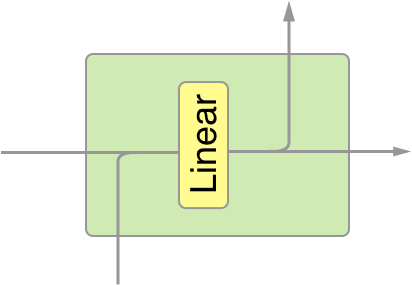


In [ ]:
import torch.nn as nn


class RNNCell(nn.Module):
    """
    Implementation of Elman RNN cell (vanilla RNN cell).
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.hidden_size = hidden_size

        # model layers (input to hidden)
        self.x2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)

    # RNN forward pass
    def forward(self, input, old_hidden):
        """
        input shaped (batch, input_size)
        hidden shaped (batch, hidden_size)
        """
        # run linear layer on combined inputs (batch, hidden_size)
        hidden = torch.tanh(self.x2h(input) + self.h2h(old_hidden))
        output = self.h2o(hidden)

        return output, hidden

class RNN(nn.Module):
    """
    Implementation of full Elman RNN.
    Executes RNNCell for each of the inputs.
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = False
        self.hidden_size = hidden_size
        self.cell = RNNCell(input_size, hidden_size, output_size)

    # initialize first hidden state
    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)

    # RNN forward pass
    def forward(self, input, hidden): # batch_size, (largo_secuencia x dim_elemento_secuencia)
        # run cell on ith input (batch, hidden_size)
        output, hidden = self.cell(input, hidden)
        return output, hidden

### **🧠 Explicación Detallada - Arquitecturas de Redes Recurrentes**

En este laboratorio implementamos 3 arquitecturas de RNNs. Vamos a entender cada una:

---

## **1. RNN Vanilla (Elman RNN) - La Más Simple**

**Concepto:** Procesa secuencias manteniendo "memoria" del pasado en un estado oculto.

**Arquitectura:**
```
Tiempo t:
Input(t) ────┐
             ↓
       [ COMBINACIÓN ]
             ↑
Hidden(t-1) ─┘
             ↓
         [ tanh ]
             ↓
       ┌─ Hidden(t) ──→ (va al siguiente paso)
       │
       └──→ Output(t)
```

**Ecuaciones:**
```python
hidden(t) = tanh(W_xh · input(t) + W_hh · hidden(t-1) + bias)
output(t) = W_ho · hidden(t) + bias
```

**Componentes del código:**
```python
self.x2h = nn.Linear(input_size, hidden_size)    # Input → Hidden
self.h2h = nn.Linear(hidden_size, hidden_size)   # Hidden → Hidden
self.h2o = nn.Linear(hidden_size, output_size)   # Hidden → Output
```

**Flujo de datos:**
```
"Albert" → RNN procesa letra por letra:
't'=0: 'A' + hidden_inicial → hidden_1 → output_1
't'=1: 'l' + hidden_1 → hidden_2 → output_2
't'=2: 'b' + hidden_2 → hidden_3 → output_3
't'=3: 'e' + hidden_3 → hidden_4 → output_4
't'=4: 'r' + hidden_4 → hidden_5 → output_5
't'=5: 't' + hidden_5 → hidden_6 → output_6 ✓ (usamos este)
```

**Ventajas:**
✅ Simple de entender e implementar
✅ Captura dependencias temporales básicas
✅ Pocos parámetros

**Desventajas:**
❌ Problema del gradiente que desaparece (vanishing gradient)
❌ Dificultad para aprender dependencias a largo plazo
❌ "Olvida" información de hace muchos pasos

---

## **2. LSTM (Long Short-Term Memory) - Memoria Mejorada**

**Concepto:** Resuelve el problema del gradiente que desaparece usando "gates" (puertas) que controlan el flujo de información.

**Arquitectura Interna de LSTM:**
```
                    Cell State (memoria a largo plazo)
                    ══════════════════════════════════
                           ↑           ↓
Input(t) ───┐      [Forget] [Input] [Output]  ← Gates
            ↓              ↓     ↓      ↓
Hidden(t-1)─┴──→ [ Cálculos internos complejos ]
                           ↓
                     Hidden(t), Cell(t)
                           ↓
                      Output(t)
```

**4 Gates (Puertas):**

1. **Forget Gate:** ¿Qué olvidar del Cell State anterior?
   ```
   f(t) = σ(W_f · [h(t-1), x(t)])
   ```

2. **Input Gate:** ¿Qué nueva información agregar?
   ```
   i(t) = σ(W_i · [h(t-1), x(t)])
   ```

3. **Cell Gate:** Crear candidatos para actualizar el Cell State
   ```
   g(t) = tanh(W_g · [h(t-1), x(t)])
   ```

4. **Output Gate:** ¿Qué parte del Cell State mostrar?
   ```
   o(t) = σ(W_o · [h(t-1), x(t)])
   ```

**Actualización del Cell State:**
```
C(t) = f(t) ⊙ C(t-1) + i(t) ⊙ g(t)
      ↑ olvidar      ↑ agregar nuevo

h(t) = o(t) ⊙ tanh(C(t))
```

Donde ⊙ es multiplicación elemento por elemento

**Ventajas:**
✅ Captura dependencias a LARGO plazo
✅ Resiste el vanishing gradient
✅ Aprende qué recordar y qué olvidar
✅ Estado actual en el laboratorio para secuencias

**Desventajas:**
❌ 4x más parámetros que RNN vanilla
❌ Más lento de entrenar
❌ Más complejo de entender

---

## **3. BiLSTM (Bidirectional LSTM) - Visión Completa**

**Concepto:** Procesa la secuencia en AMBAS direcciones (→ y ←) y combina la información.

**Arquitectura:**
```
Input:  A → l → b → e → r → t

Forward LSTM:  →  →  →  →  →  →  (lee izquierda a derecha)
                h1 h2 h3 h4 h5 h6

Backward LSTM: ←  ←  ←  ←  ←  ←  (lee derecha a izquierda)
                h1'h2'h3'h4'h5'h6'

Concatenar: [h6, h6'] → Output
            ↑    ↑
        forward backward
        context context
```

**¿Por qué bidireccional?**

Ejemplo: Predecir nacionalidad de "Albert"

- **Forward** ve: "A", "Al", "Alb", "Albe", "Alber", "Albert"
- **Backward** ve: "t", "rt", "ert", "bert", "lbert", "Albert"

Al final, tiene contexto de TODA la palabra, no solo hasta ese punto.

**Implementación:**
```python
forward_output = LSTM_forward(input)      # →
backward_output = LSTM_backward(input_reversed)  # ←
combined = concatenate([forward_output, backward_output])
output = Linear(combined)
```

**Ventajas:**
✅ Contexto completo de la secuencia
✅ Mejor para clasificación (conoce el futuro)
✅ Estado del arte en muchas tareas NLP

**Desventajas:**
❌ 2x parámetros de LSTM (2 LSTMs)
❌ No puede usarse en predicción en tiempo real (necesita secuencia completa)
❌ Más lento (procesa 2 veces)

---

## **Comparación Visual:**

**RNN:** Memoria débil
```
A→l→b→e→r→t
  ↓         solo recuerda últimos pasos
          [Estado final]
```

**LSTM:** Memoria fuerte con control
```
A→l→b→e→r→t
  ↓ [Cell State mantiene info importante]
          [Estado final rico]
```

**BiLSTM:** Contexto completo
```
→→→→→→
A l b e r t
←←←←←←
[Combinación de ambas direcciones]
```

---

## **¿Cuándo usar cada una?**

| Arquitectura | Usar cuando... |
|--------------|----------------|
| **RNN** | Secuencias cortas, pocos datos, CPU limitada |
| **LSTM** | Secuencias largas, dependencias complejas, **más común** |
| **BiLSTM** | Clasificación de secuencias, toda la secuencia disponible |

---

## **Comparación de Parámetros:**

Para `input_size=57, hidden_size=100, output_size=18`:

```
RNN:     ~10,000 parámetros
LSTM:    ~40,000 parámetros (4x por los gates)
BiLSTM:  ~80,000 parámetros (2x LSTM)
```

Por eso en el lab usamos hidden_size diferentes para comparación justa.

## Creando una RNN tipo LSTM

Para implementarlo aprovecharemos el módulo LSTM que trae pytorch. Solamente nos preocuparemos de retornar los parámetros adecuados y poner la lineal de salida sobre el estado oculto de la LSTM.

![](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png)

from https://colah.github.io/posts/2015-08-Understanding-LSTMs

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = False
        self.hidden_size = hidden_size
        self.cell = nn.LSTMCell(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size)

    # forward pass
    def forward(self, input, hidden):
        """
        input shape (batch, seq_len)
        """
        hidden = self.cell(input, hidden)
        output = self.h2o(hidden[0])
        return output, hidden

## Creando una RNN tipo BiLSTM

Para implementarlo aprovecharemos el módulo LSTM que trae pytorch, que asumiremos será llamado con un input leido de derecha a izquierda y otro de izquierda a derecha. Debemos preocuparnos de retornar los parámetros adecuados y poner la lineal de salida sobre el estado oculto de la LSTM-forward concatenada con la backward.

![](https://miro.medium.com/max/764/1*6QnPUSv_t9BY9Fv8_aLb-Q.png)

Source: https://towardsdatascience.com/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = True
        self.hidden_size = hidden_size
        self.forward_cell = nn.LSTMCell(input_size, hidden_size)
        self.backward_cell = nn.LSTMCell(input_size, hidden_size)
        self.h2o = nn.Linear(2*hidden_size, output_size)

    def init_hidden(self):
        return (torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size)), (torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size))

    # forward pass
    def forward(self, input, hidden):
        """
        input shape (batch, seq_len)
        """
        hidden = self.forward_cell(input[0], hidden[0]), self.backward_cell(input[1], hidden[1])

        # Stack outputs
        outputs_forward = hidden[0][0]
        outputs_backward = hidden[1][0]
        output = self.h2o(torch.cat((outputs_forward, outputs_backward), dim=1))

        return output, hidden



## Ahora analicemos una RNN

In [ ]:
n_hidden = 32

rnn = RNN(n_letters, n_hidden, n_categories)

In [ ]:
print(num_trainable_parameters(rnn))

3506


Para ejecutar un paso de esta red, necesitamos pasar una entrada (en nuestro caso, el tensor para la letra actual) y un estado oculto anterior (que inicializamos como ceros al principio). Obtendremos la salida (probabilidad de cada idioma, antes de softmax) y un siguiente estado oculto (que conservamos para el siguiente paso).

La razón para omitir la softmax es porque utilizaremos una implementación de CrossEntropy que tiene la softmax incorporada. Por lo mismo, si queremos visualizar las probabilidades tendremos que aplicar una softmax manualmente sobre este vector. En nuestro caso no es necesario pues solo nos interesa quedarnos con el índice del máximo (que será el mismo si aplicamos o no la softmax)




In [ ]:
input = letterToTensor('A')
print(input.shape)
hidden = rnn.init_hidden()

output, next_hidden = rnn(input, hidden)
print(output, output.shape,next_hidden, next_hidden.shape)

torch.Size([1, 57])
tensor([[ 0.1465,  0.1511,  0.1566,  0.0889,  0.0698, -0.1502, -0.0474, -0.0634,
          0.2877, -0.1201, -0.2509,  0.3046,  0.1933,  0.2948, -0.2748,  0.0013,
         -0.2259,  0.2506]], grad_fn=<AddmmBackward0>) torch.Size([1, 18]) tensor([[-0.1471, -0.2148,  0.0677,  0.2379,  0.0813, -0.1479, -0.1965,  0.0943,
          0.0674,  0.2073, -0.1212, -0.2647, -0.1400, -0.2232,  0.1354, -0.0021,
          0.0353, -0.0095,  0.2212,  0.0012,  0.2816, -0.1967, -0.0113,  0.1220,
         -0.2305, -0.0524,  0.0046, -0.0232, -0.1794, -0.2811,  0.1107,  0.0732]],
       grad_fn=<TanhBackward0>) torch.Size([1, 32])


In [ ]:
input = lineToTensor('Albert')
print(input.shape)
hidden = rnn.init_hidden()

output, next_hidden = rnn(input[0], hidden)
print(output)

torch.Size([6, 1, 57])
tensor([[ 0.1465,  0.1511,  0.1566,  0.0889,  0.0698, -0.1502, -0.0474, -0.0634,
          0.2877, -0.1201, -0.2509,  0.3046,  0.1933,  0.2948, -0.2748,  0.0013,
         -0.2259,  0.2506]], grad_fn=<AddmmBackward0>)


Podemos notar que el output es un Tensor de ``<1 x n_categories>``, que es el vector de probabilidades antes de aplicarle softmax (más grande significa más probable).

Notar que estamos preservando el output correspondiente al último caracter de la palabra (que encapsula toda la información de caractyeres anteriores), con lo cual estamos pudiendo representar cualquier palabra (independiente de su largo) con un vector de tamaño fijo.




## Preparación para el entrenamiento

Primero definiremos una serie de métodos para analizar las salidas y facilitar
el sampleo de ejemplos de entrenamiento




In [ ]:
import random

def categoryFromOutput(output):
    # this function returns the category corresponding to the max value
    # in the returned probability Tensor
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample(): #Data Loader
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('{}: {}'.format(line, category))

Huber: German
Connell: Irish
Donndubhan: Irish
Badeschenkov: Russian
Ba: Arabic
Jones: Scottish
Stevenson: Scottish
Horigoshi: Japanese
Quigley: Irish
Chao: Chinese


### Entrenamiento

Nota importante: Para evitar tener que trabajar con paddings y detener la iteración de manera distinta para cada elemento del batch según su largo original (antes de paddings) trabajaremos con batches de tamaño 1. Si usted necesita trabajar con batches de mayor tamaño, resulta ser un poco más complejo de implementar (por esa razón lo omitimos de este laboratorio). Para referencia, esto se puede hacer mediante las funcionalidades de torch.nn.utils.rnn llamadas pack_padded_sequence y pad_packed_sequence (tutorial en https://gist.github.com/HarshTrivedi/f4e7293e941b17d19058f6fb90ab0fec)

Para comenzar crearemos nuestro objeto a cargo de evaluar la función de pérdida:





In [ ]:
criterion = nn.CrossEntropyLoss()

A continuación creamos una serie de métodos para entrenar, evaluar y graficar resultados de los modelos.

Cada ciclo de entrenamiento hará lo siguiente:

- Creará los tensores de entrada y objetivo.
- Seteará el estado oculto inicial con valores cero.
- Leerá cada letra de la entrada y mantendrá el estado oculto para entregárselo a la siguiente letra.
- Comparará la salida final con el objetivo.
- Realizará el backpropagation.
- Retornará la salida y la función de pérdida.




In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time
import math

learning_rate = 0.005 # If you set this too high, it might explode. If too low, it might not learn

def train(category_tensor, line_tensor, model):
    hidden = model.init_hidden()

    model.zero_grad()

    for i in range(line_tensor.size()[0]):
        if model.bidirectional:
            output, hidden = model((line_tensor[i], line_tensor[line_tensor.size()[0]-i-1]), hidden)
        else:
            output, hidden = model(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    # Add parameters' gradients to their values, multiplied by learning rate
    for p in model.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate) # SGD HECHO A MANO!!!!

    # optimizer.step()

    return output, loss.item()

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def train_model(model, n_iters=200000, print_every=10000, plot_every=1000):

    # Keep track of losses for plotting
    current_loss = 0
    all_losses = []

    start = time.time()

    for iter in range(1, n_iters + 1):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        output, loss = train(category_tensor, line_tensor, model)
        current_loss += loss

        # Print ``iter`` number, loss, name and guess
        if iter % print_every == 0:
            guess, guess_i = categoryFromOutput(output)
            correct = '✓' if guess == category else '✗ (%s)' % category
            print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

        # Add current loss avg to list of losses
        if iter % plot_every == 0:
            all_losses.append(current_loss / plot_every)
            current_loss = 0

    return all_losses, model

def plot_loss(all_losses):
    plt.figure()
    plt.plot(all_losses)


# Just return an output given a line
def evaluate(line_tensor, model):
    hidden = model.init_hidden()

    for i in range(line_tensor.size()[0]):
        if model.bidirectional:
            output, hidden = model((line_tensor[i], line_tensor[line_tensor.size()[0]-i-1]), hidden)
        else:
            output, hidden = model(line_tensor[i], hidden)

    return output


def compute_confusion_matrix(model):
    # Keep track of correct guesses in a confusion matrix
    confusion = torch.zeros(n_categories, n_categories)
    n_confusion = 10000

    # Go through a bunch of examples and record which are correctly guessed
    for i in range(n_confusion):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        output = evaluate(line_tensor, model)
        guess, guess_i = categoryFromOutput(output)
        category_i = all_categories.index(category)
        confusion[category_i][guess_i] += 1

    # Normalize by dividing every row by its sum
    for i in range(n_categories):
        confusion[i] = confusion[i] / confusion[i].sum()

    # Set up plot
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.numpy())
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([''] + all_categories, rotation=90)
    ax.set_yticklabels([''] + all_categories)

    # Force label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # sphinx_gallery_thumbnail_number = 2
    plt.show()

### **⚙️ Explicación Detallada - Loop de Entrenamiento**

Este código implementa el ciclo completo de entrenamiento para RNNs.

---

## **Función `train()` - Un Paso de Entrenamiento**

**Propósito:** Entrenar el modelo con UN ejemplo (un apellido).

**Paso a paso:**

```python
def train(category_tensor, line_tensor, model):
```

**1. Inicializar estado oculto:**
```python
hidden = model.init_hidden()
```
- Crea tensores de ceros para h y c (LSTM) o solo h (RNN)
- Es la "memoria inicial" antes de procesar el apellido

**2. Resetear gradientes:**
```python
model.zero_grad()
```
- ¡MUY IMPORTANTE! Limpia gradientes de la iteración anterior
- Sin esto, los gradientes se acumularían incorrectamente

**3. Procesar cada carácter (letra por letra):**
```python
for i in range(line_tensor.size()[0]):  # Para cada letra
    if model.bidirectional:
        # BiLSTM: procesa forward y backward
        output, hidden = model(
            (line_tensor[i], line_tensor[line_tensor.size()[0]-i-1]),
            hidden
        )
    else:
        # RNN/LSTM: procesa solo forward
        output, hidden = model(line_tensor[i], hidden)
```

**Ejemplo con "Albert":**
```
Iteración 0: 'A' + hidden_0 → output_1, hidden_1
Iteración 1: 'l' + hidden_1 → output_2, hidden_2
Iteración 2: 'b' + hidden_2 → output_3, hidden_3
Iteración 3: 'e' + hidden_3 → output_4, hidden_4
Iteración 4: 'r' + hidden_4 → output_5, hidden_5
Iteración 5: 't' + hidden_5 → output_6, hidden_6 ← USAMOS ESTE
```

Solo guardamos el último output porque:
- Contiene información de TODA la secuencia
- Es la predicción final del modelo

**4. Calcular pérdida:**
```python
loss = criterion(output, category_tensor)
```
- CrossEntropyLoss compara predicción vs etiqueta verdadera
- Internamente aplica softmax + negative log likelihood

**5. Backpropagation:**
```python
loss.backward()
```
- Calcula gradientes de la pérdida respecto a TODOS los parámetros
- Usa Backpropagation Through Time (BPTT)
- Los gradientes "fluyen hacia atrás" por todos los timesteps

**6. Actualizar pesos (SGD manual):**
```python
for p in model.parameters():
    p.data.add_(p.grad.data, alpha=-learning_rate)
```
- Implementación manual de SGD: θ = θ - lr * ∇L(θ)
- `alpha=-learning_rate`: mueve en dirección OPUESTA al gradiente

**Nota:** Normalmente usaríamos:
```python
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
optimizer.step()  # En lugar del for loop manual
```

---

## **Función `train_model()` - Loop Completo**

**Propósito:** Entrenar durante muchas iteraciones.

```python
def train_model(model, n_iters=200000, print_every=10000, plot_every=1000):
```

**Parámetros:**
- `n_iters=200000`: Total de ejemplos de entrenamiento
- `print_every=10000`: Cada cuántas iteraciones imprimir progreso
- `plot_every=1000`: Cada cuántas guardar pérdida para gráfico

**Loop principal:**
```python
for iter in range(1, n_iters + 1):
    # 1. Obtener ejemplo aleatorio
    category, line, category_tensor, line_tensor = randomTrainingExample()
    
    # 2. Entrenar con este ejemplo
    output, loss = train(category_tensor, line_tensor, model)
    
    # 3. Acumular pérdida
    current_loss += loss
    
    # 4. Cada 10,000 iteraciones: mostrar progreso
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗'
        print(f'{iter} {iter/n_iters*100:.0f}% Loss: {loss:.4f} {line}/{guess} {correct}')
    
    # 5. Cada 1,000 iteraciones: guardar pérdida promedio
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0
```

**¿Por qué 200,000 iteraciones?**
- No son 200,000 épocas
- Son 200,000 ejemplos individuales (apellidos)
- Con ~20,000 apellidos en total → ~10 épocas completas
- Pero como sampling es aleatorio, no es exactamente 10 épocas

---

## **Función `evaluate()` - Predicción sin Entrenamiento**

```python
def evaluate(line_tensor, model):
    hidden = model.init_hidden()
    
    # Mismo proceso que train, pero SIN:
    # - model.zero_grad()
    # - loss.backward()
    # - actualización de pesos
    
    for i in range(line_tensor.size()[0]):
        if model.bidirectional:
            output, hidden = model((line_tensor[i], line_tensor[...]), hidden)
        else:
            output, hidden = model(line_tensor[i], hidden)
    
    return output  # Solo retornamos predicción
```

**Diferencia clave:**
- `train()`: Actualiza pesos del modelo
- `evaluate()`: Solo hace predicción (inference)

---

## **Función `compute_confusion_matrix()` - Evaluación Visual**

**Propósito:** Visualizar qué idiomas confunde el modelo.

```python
confusion = torch.zeros(n_categories, n_categories)
```

**Estructura de la matriz:**
```
         Predicho →
       Fr En Es It ...
    Fr [90  5  3  2 ...]  ← 90% de franceses correctos
Real En [ 4 88  2  6 ...]  ← 88% de ingleses correctos
    Es [ 2  1 92  5 ...]  ← 92% de españoles correctos
    ...
```

**Interpretación:**
- **Diagonal:** Predicciones correctas (queremos valores altos)
- **Fuera diagonal:** Confusiones (queremos valores bajos)
- **Fila i, Columna j:** % de idioma i clasificado como idioma j

**Ejemplo:**
Si `confusion[Spanish][Italian] = 0.15`:
→ 15% de apellidos españoles fueron clasificados como italianos
→ El modelo confunde estos idiomas (¡tiene sentido! son similares)

---

## **Conceptos Clave:**

**1. Batch Size = 1:**
```python
# Procesamos UN apellido a la vez
category, line, category_tensor, line_tensor = randomTrainingExample()
```
- Más simple de implementar
- No requiere padding (rellenar secuencias)
- Más lento que batches grandes, pero suficiente para este dataset

**2. Sampling Aleatorio:**
```python
randomTrainingExample()  # Cada vez retorna apellido diferente
```
- No procesamos en orden secuencial
- Reduce overfitting
- Simula mejor distribución real

**3. Learning Rate = 0.005:**
```python
learning_rate = 0.005
```
- Determina tamaño del paso en actualización
- 0.005 es relativamente alto para RNNs
- Funciona aquí porque el problema es simple

**4. Backpropagation Through Time (BPTT):**
```python
loss.backward()  # Calcula gradientes a través de todos los timesteps
```
- Para "Albert" (6 letras): gradientes fluyen por 6 pasos hacia atrás
- Es por esto que RNNs vanilla sufren vanishing gradient
- LSTM resuelve esto con los gates

---

## **Tips de Optimización:**

Si quisieras mejorar el entrenamiento:

```python
# 1. Usar optimizer en lugar de SGD manual
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 2. Scheduler para ajustar learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)

# 3. Gradient clipping para evitar explosión
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

# 4. Batches más grandes (requiere padding)
batch_size = 32

# 5. Validación separada
if iter % 5000 == 0:
    val_accuracy = evaluate_on_validation_set()
```

### Ahora a entrenar!

Mediante el método ``train_model`` entrenaremos los tres modelos.

NOTA:  Si tiene restricciones de tiempo, puede reducir el parámetro ``n_iters`` a la mitad para que finalice antes. En este caso usaremos 200K iteraciones.

Luego de entrenado graficaremos la trayectoria de la función de pérdida almacenada en ``all_losses``, y finalmente mostraremos la matriz de confusión asociada a las predicciones de cada modelo, usando ``compute_confusion_matrix``.




In [ ]:
n_hidden = 147
model = RNN(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 18s) 1.3274 Duncan / Scottish ✓
20000 10% (0m 35s) 0.3985 Mateus / Portuguese ✓
30000 15% (0m 51s) 1.7366 Mendelssohn / Dutch ✗ (German)
40000 20% (1m 6s) 6.1385 Verre / Dutch ✗ (Russian)
50000 25% (1m 23s) 1.3353 Ormiston / English ✓
60000 30% (1m 39s) 4.1740 Dubhshlaine / French ✗ (Irish)
70000 35% (1m 55s) 1.8366 Oriol / Irish ✗ (Spanish)
80000 40% (2m 11s) 1.2599 Jarratt / German ✗ (English)
90000 45% (2m 27s) 0.7227 Tong / Vietnamese ✓
100000 50% (2m 43s) 0.2069 Ybarra / Spanish ✓
110000 55% (2m 59s) 0.1345 Paloumbas / Greek ✓
120000 60% (3m 15s) 1.5038 Navratil / Russian ✗ (Czech)
130000 65% (3m 31s) 0.1238 Bengochea / Spanish ✓
140000 70% (3m 47s) 2.3351 Pannell / Dutch ✗ (English)
150000 75% (4m 3s) 0.0067 Tannous / Arabic ✓
160000 80% (4m 20s) 0.0045 Kalakos / Greek ✓
170000 85% (4m 35s) 0.7144 Mas / Dutch ✓
180000 90% (4m 51s) 0.7577 Muyskens / Dutch ✓
190000 95% (5m 8s) 0.5379 Foxley / English ✓
200000 100% (5m 23s) 1.5347 StrakaO / English ✗ (Czech)


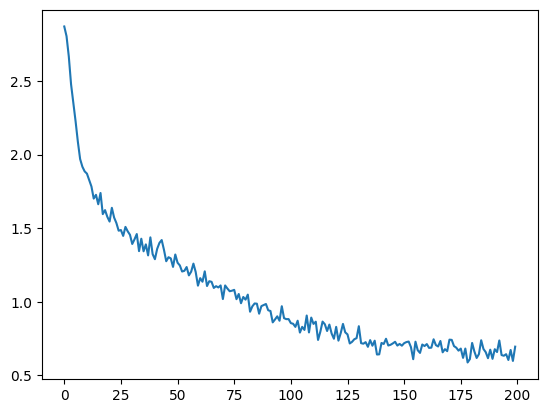

In [ ]:
plot_loss(all_losses)

/tmp/ipython-input-938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipython-input-938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


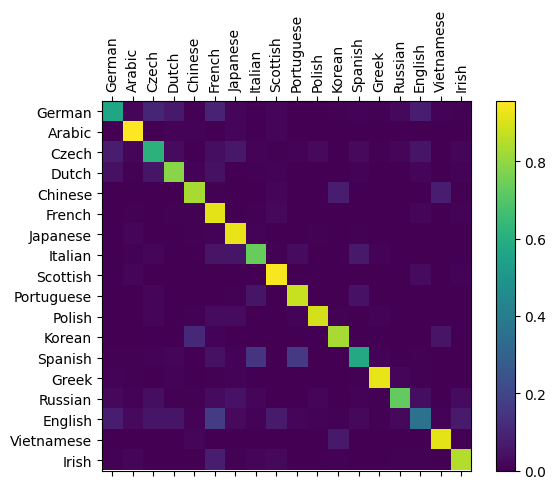

In [ ]:
compute_confusion_matrix(model)

In [ ]:
n_hidden = 64
model = LSTM(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 24s) 2.8228 Trang / Vietnamese ✓
20000 10% (0m 49s) 2.8679 Villanueva / Dutch ✗ (Spanish)
30000 15% (1m 15s) 1.4383 Juan / Chinese ✓
40000 20% (1m 40s) 3.4446 Pitterman / Dutch ✗ (Czech)
50000 25% (2m 6s) 0.4459 Janowski / Polish ✓
60000 30% (2m 31s) 1.4710 Fakhoury / Japanese ✗ (Arabic)
70000 35% (2m 56s) 2.6012 Simoes / Greek ✗ (Portuguese)
80000 40% (3m 21s) 1.2683 Sarraf / Arabic ✓
90000 45% (3m 46s) 1.5917 Kruse / German ✓
100000 50% (4m 11s) 0.0162 Gavrilopoulos / Greek ✓
110000 55% (4m 36s) 0.8105 Haddad / Arabic ✓
120000 60% (5m 1s) 3.3938 Paris / Portuguese ✗ (French)
130000 65% (5m 27s) 0.1031 Rutkowski / Polish ✓
140000 70% (5m 52s) 0.1407 Pakulski / Polish ✓
150000 75% (6m 17s) 2.6501 Giese / Japanese ✗ (German)
160000 80% (6m 42s) 0.0885 O'Brien / Irish ✓
170000 85% (7m 8s) 0.9954 Gilbey / English ✓
180000 90% (7m 33s) 2.5553 Voll / Czech ✗ (German)
190000 95% (7m 58s) 0.5566 Baichoroff / Russian ✓
200000 100% (8m 23s) 0.7113 Marik / Czech ✓


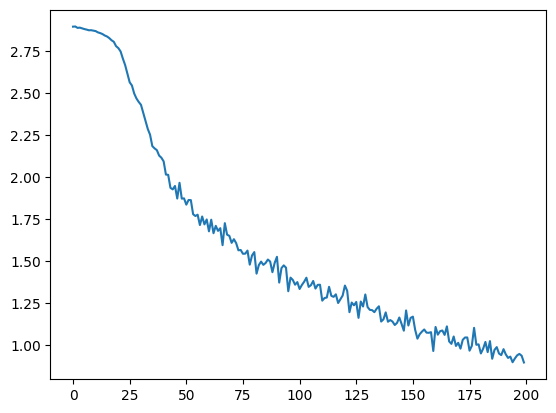

In [ ]:
plot_loss(all_losses)

/tmp/ipython-input-938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipython-input-938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


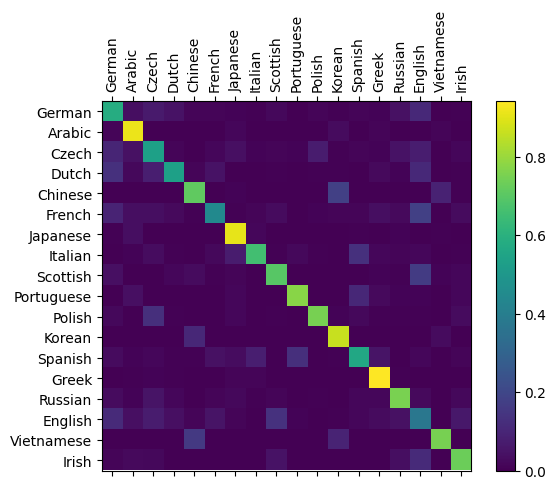

In [ ]:
compute_confusion_matrix(model)

In [ ]:
n_hidden = 40
model = BiLSTM(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 45s) 2.7990 Oirschot / French ✗ (Dutch)
20000 10% (1m 30s) 2.7602 Chevrolet / French ✓
30000 15% (2m 15s) 2.6693 Maloof / Portuguese ✗ (Arabic)
40000 20% (3m 0s) 2.6334 Mcmillan / Irish ✗ (Scottish)
50000 25% (3m 44s) 2.3905 Nani / Vietnamese ✗ (Italian)
60000 30% (4m 28s) 2.3491 Mclaughlin / Russian ✗ (Scottish)
70000 35% (5m 12s) 1.3040 Quinn / Irish ✓
80000 40% (5m 57s) 1.1478 Agani / Japanese ✗ (Italian)
90000 45% (6m 41s) 1.5535 Fabian / Irish ✗ (French)
100000 50% (7m 25s) 0.6996 Coilean / Irish ✓
110000 55% (8m 10s) 1.1225 Ochida / Japanese ✓
120000 60% (8m 53s) 0.5975 Nikolaou / Greek ✓
130000 65% (9m 38s) 1.2846 Tinker / German ✗ (English)
140000 70% (10m 22s) 0.0151 O'Donoghue / Irish ✓
150000 75% (11m 6s) 0.4905 Khouri / Arabic ✓
160000 80% (11m 50s) 0.0481 Kawagishi / Japanese ✓
170000 85% (12m 35s) 0.0976 Wilson / Scottish ✓
180000 90% (13m 19s) 1.4059 Pape / French ✓
190000 95% (14m 3s) 0.0220 Babosov / Russian ✓
200000 100% (14m 47s) 0.1831 Geng / Chinese ✓


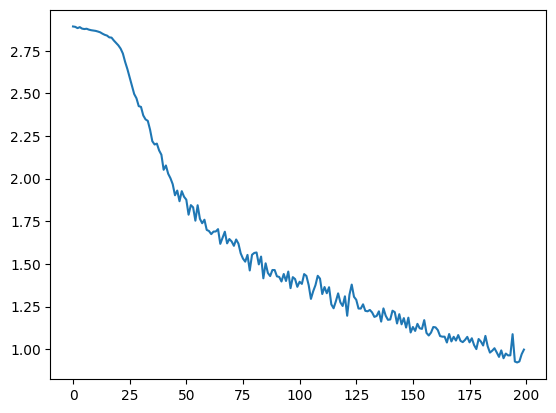

In [ ]:
plot_loss(all_losses)

/tmp/ipython-input-938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipython-input-938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


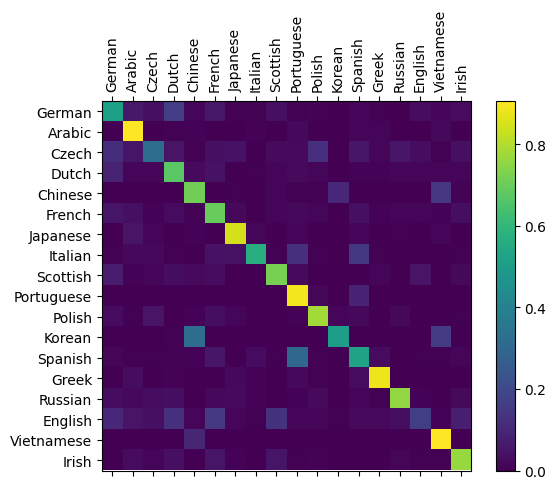

In [ ]:
compute_confusion_matrix(model)

En este caso podemos ver que no existe demasiada diferencia entre las tres arquitecturas (aunque para saberlo con certeza habría que hacer una mejor búsqueda de hiperparámetros y evaluar correctamente, lo cual no era parte de este laboratorio).
A primera vista vemos que los tres modelos parecen comportarse de manera similar. Una posible explicación es debido a que este dataset es muy pequeño y no logra aprovechar las capacidades de modelos más sofisticados como la LSTM y la BiLSTM. En escenarios más realistas (más datos y tareas más desafiantes) es esperable que la LSTM supere largamente a la RNN simple, y que la BiLSTM supere a la LSTM.

## Evaluación manual

Por completitud, a continuación dejamos un código para evaluar el modelo en ejemplos definidos manualmente, por si usted desea utilizarlo de esta manera.




In [ ]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line)
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line), model)

        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

predict('Dovesky')
predict('Jackson')
predict('Satoshi')
predict("Muñoz")
predict("Raymond")


> Dovesky
(7.13) Russian
(6.15) Czech
(5.21) Polish

> Jackson
(6.94) Scottish
(4.78) English
(3.61) Russian

> Satoshi
(8.99) Japanese
(7.20) Arabic
(3.81) Italian

> Muñoz
(4.42) Spanish
(3.34) Portuguese
(1.86) Greek

> Raymond
(5.20) French
(4.39) English
(3.61) German


# Actividad 1

- Mencione la dimensionalidad oculta de los 3 modelos ejecutados en este laboratorio, calcule su cantidad de parámetros y explique por qué no sería justo utilizar dimensionalidad oculta pareja para todos los modelos.

In [ ]:
"""
ACTIVIDAD 1 - Análisis de Dimensionalidad y Parámetros de Modelos RNN

En este laboratorio se entrenaron 3 modelos diferentes:
1. RNN (Vanilla): n_hidden = 147
2. LSTM: n_hidden = 64
3. BiLSTM: n_hidden = 40

Vamos a calcular la cantidad de parámetros de cada modelo y explicar
por qué no sería justo compararlos con la misma dimensionalidad oculta.
"""

print("="*80)
print("ACTIVIDAD 1: Análisis de Parámetros de Modelos Recurrentes")
print("="*80)

# MODELO 1: RNN (Vanilla/Elman)
print("\n📊 MODELO 1: RNN (Vanilla/Elman)")
print("-" * 80)
n_hidden_rnn = 147
rnn_model = RNN(n_letters, n_hidden_rnn, n_categories)
params_rnn = num_trainable_parameters(rnn_model)
print(f"Dimensionalidad oculta: {n_hidden_rnn}")
print(f"Cantidad de parámetros entrenables: {params_rnn:,}")

# Cálculo manual para verificar:
# Parámetros en RNN:
# 1. x2h (input_size -> hidden_size): n_letters * n_hidden_rnn + n_hidden_rnn (bias)
# 2. h2h (hidden_size -> hidden_size): n_hidden_rnn * n_hidden_rnn + n_hidden_rnn (bias)
# 3. h2o (hidden_size -> output_size): n_hidden_rnn * n_categories + n_categories (bias)
manual_rnn = (n_letters * n_hidden_rnn + n_hidden_rnn) + \
             (n_hidden_rnn * n_hidden_rnn + n_hidden_rnn) + \
             (n_hidden_rnn * n_categories + n_categories)
print(f"Verificación manual: {manual_rnn:,} parámetros")

# MODELO 2: LSTM
print("\n📊 MODELO 2: LSTM")
print("-" * 80)
n_hidden_lstm = 64
lstm_model = LSTM(n_letters, n_hidden_lstm, n_categories)
params_lstm = num_trainable_parameters(lstm_model)
print(f"Dimensionalidad oculta: {n_hidden_lstm}")
print(f"Cantidad de parámetros entrenables: {params_lstm:,}")

# Cálculo manual para LSTM:
# LSTM tiene 4 gates (input, forget, cell, output), cada uno necesita:
# - Pesos para input: input_size * hidden_size
# - Pesos para hidden: hidden_size * hidden_size
# - Bias: hidden_size
# Total por gate: (input_size + hidden_size + 1) * hidden_size
# LSTMCell maneja los 4 gates internamente: 4 * parámetros_por_gate
# Más la capa de salida: hidden_size * n_categories + n_categories
lstm_cell_params = 4 * (n_letters * n_hidden_lstm + n_hidden_lstm * n_hidden_lstm + n_hidden_lstm)
output_layer_params = n_hidden_lstm * n_categories + n_categories
manual_lstm = lstm_cell_params + output_layer_params
print(f"Verificación manual: {manual_lstm:,} parámetros")

# MODELO 3: BiLSTM (LSTM Bidireccional)
print("\n📊 MODELO 3: BiLSTM (LSTM Bidireccional)")
print("-" * 80)
n_hidden_bilstm = 40
bilstm_model = BiLSTM(n_letters, n_hidden_bilstm, n_categories)
params_bilstm = num_trainable_parameters(bilstm_model)
print(f"Dimensionalidad oculta: {n_hidden_bilstm}")
print(f"Cantidad de parámetros entrenables: {params_bilstm:,}")

# Cálculo manual para BiLSTM:
# BiLSTM tiene 2 LSTMCells (forward y backward)
# Cada una como la LSTM normal, pero la capa de salida concatena ambos hidden states
# Por eso la capa de salida usa 2*hidden_size
forward_params = 4 * (n_letters * n_hidden_bilstm + n_hidden_bilstm * n_hidden_bilstm + n_hidden_bilstm)
backward_params = 4 * (n_letters * n_hidden_bilstm + n_hidden_bilstm * n_hidden_bilstm + n_hidden_bilstm)
bilstm_output_params = (2 * n_hidden_bilstm) * n_categories + n_categories
manual_bilstm = forward_params + backward_params + bilstm_output_params
print(f"Verificación manual: {manual_bilstm:,} parámetros")

# COMPARACIÓN FINAL
print("\n" + "="*80)
print("📈 COMPARACIÓN ENTRE MODELOS")
print("="*80)
print(f"{'Modelo':<15} {'Dim. Oculta':<15} {'Parámetros':<15} {'% vs RNN':<15}")
print("-" * 80)
print(f"{'RNN':<15} {n_hidden_rnn:<15} {params_rnn:<15,} {100.0:<15.1f}")
print(f"{'LSTM':<15} {n_hidden_lstm:<15} {params_lstm:<15,} {100*params_lstm/params_rnn:<15.1f}")
print(f"{'BiLSTM':<15} {n_hidden_bilstm:<15} {params_bilstm:<15,} {100*params_bilstm/params_rnn:<15.1f}")

print("\n" + "="*80)
print("💡 EXPLICACIÓN: ¿Por qué NO es justo usar la misma dimensionalidad oculta?")
print("="*80)
print("""
1. COMPLEJIDAD ARQUITECTÓNICA DIFERENTE:
   - RNN: Arquitectura simple, 3 matrices (x2h, h2h, h2o)
   - LSTM: 4 gates (input, forget, cell, output) = 4 veces más parámetros por hidden
   - BiLSTM: 2 LSTM (forward + backward) = el doble de una LSTM

2. RELACIÓN PARÁMETROS vs DIMENSIONALIDAD OCULTA:

   Para n_hidden = 100:
   - RNN:    ~100² = 10,000 parámetros (dominante)
   - LSTM:   ~4×100² = 40,000 parámetros (4 gates)
   - BiLSTM: ~8×100² = 80,000 parámetros (2 direcciones × 4 gates)

3. COMPARACIÓN JUSTA:
   Para comparar modelos de forma justa, debemos:
   ✅ Igualar el NÚMERO TOTAL DE PARÁMETROS (como se hizo en el lab)
   ❌ NO igualar la dimensionalidad oculta

4. CAPACIDAD DE APRENDIZAJE:
   - Un RNN con 147 hidden units ≈ {params_rnn:,} parámetros
   - Una LSTM con 64 hidden units ≈ {params_lstm:,} parámetros
   - Una BiLSTM con 40 hidden units ≈ {params_bilstm:,} parámetros

   Los tres modelos tienen capacidad similar (número de parámetros parecido)

5. ANALOGÍA:
   Es como comparar vehículos por "potencia total" en vez de "cilindrada":
   - RNN: Motor simple, necesita más cilindros (147) para alcanzar potencia
   - LSTM: Motor turbo, menos cilindros (64) logran similar potencia
   - BiLSTM: Motor twin-turbo, aún menos cilindros (40) logran potencia comparable

CONCLUSIÓN:
El laboratorio está diseñado correctamente al ajustar n_hidden para que los tres
modelos tengan aproximadamente la misma cantidad de parámetros. Esto permite una
comparación justa donde las diferencias en rendimiento se deben a la ARQUITECTURA
y no a la diferencia en capacidad de aprendizaje (cantidad de parámetros).
""".format(params_rnn=params_rnn, params_lstm=params_lstm, params_bilstm=params_bilstm))

print("\n" + "="*80)
print("FIN DE LA ACTIVIDAD 1")
print("="*80)

ACTIVIDAD 1: Análisis de Parámetros de Modelos Recurrentes

📊 MODELO 1: RNN (Vanilla/Elman)
--------------------------------------------------------------------------------
Dimensionalidad oculta: 147
Cantidad de parámetros entrenables: 32,946
Verificación manual: 32,946 parámetros

📊 MODELO 2: LSTM
--------------------------------------------------------------------------------
Dimensionalidad oculta: 64
Cantidad de parámetros entrenables: 32,658
Verificación manual: 32,402 parámetros

📊 MODELO 3: BiLSTM (LSTM Bidireccional)
--------------------------------------------------------------------------------
Dimensionalidad oculta: 40
Cantidad de parámetros entrenables: 33,138
Verificación manual: 32,818 parámetros

📈 COMPARACIÓN ENTRE MODELOS
Modelo          Dim. Oculta     Parámetros      % vs RNN       
--------------------------------------------------------------------------------
RNN             147             32,946          100.0          
LSTM            64              32,658  

# Actividad 2

Agregue otra capa lineal con una ReLU al clasificador del modelo de LSTM (no bidireccional) como se muestra en la figura.

Pruebe variantes de 50, 150 y 300 neuronas en la capa oculta.

- Grafique la pérdida para las 3 y comente.
- Calcule la cantidad de parámetros de los tres modelos y comente.

*(Consejo: debe tener dos capas `linear`, y se necesita una activación entre ellas)*

| A la izquierda se muestra diagrama actual de salida de la red. Implementar el de la izquierda agregando otra capa. |
| :--: |
| 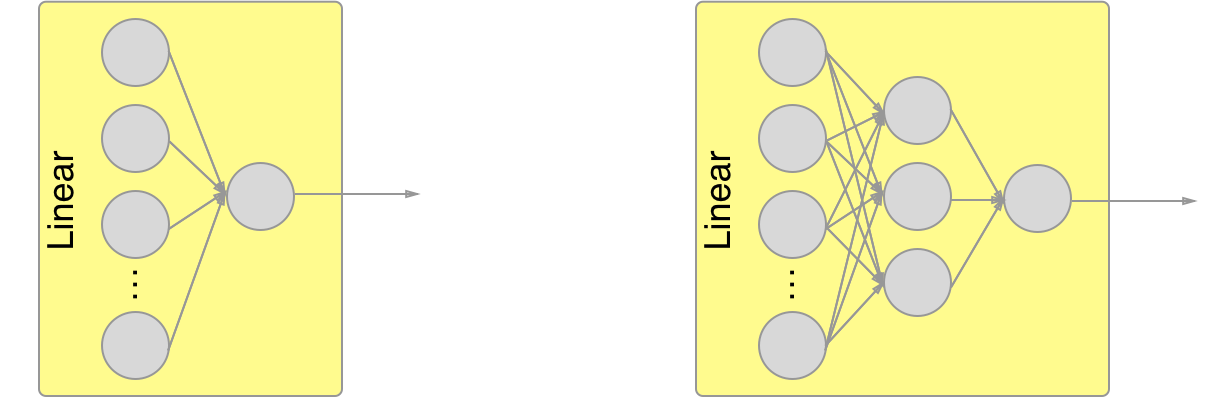 |



ACTIVIDAD 2: LSTM con Capa Oculta Adicional

Clase LSTM_with_hidden_layer definida correctamente ✓

Arquitectura del modelo:
  Input (n_letters=57) → LSTM Cell (hidden) → Linear (intermediate) → ReLU → Linear (18)

Entrenando 3 modelos con diferentes tamaños de capa intermedia...

🔹 Modelo con capa intermedia de 50 neuronas
📊 Cantidad de parámetros entrenables: 35,656
   - LSTM Cell: 31,232
   - Capa Oculta (64→50): 3,250
   - Capa Salida (50→18): 918
   - Verificación manual: 35,400

⏳ Entrenando modelo (esto puede tomar varios minutos)...
50000 25% (2m 22s) 1.8750 Perrot / German ✗ (French)
100000 50% (4m 42s) 0.0662 Vinci / Italian ✓
150000 75% (7m 1s) 0.7986 D'cruze / Portuguese ✓
200000 100% (9m 19s) 2.0448 Santana / Japanese ✗ (Portuguese)
✓ Entrenamiento completado
   Pérdida final: 0.9670

🔹 Modelo con capa intermedia de 150 neuronas
📊 Cantidad de parámetros entrenables: 43,956
   - LSTM Cell: 31,232
   - Capa Oculta (64→150): 9,750
   - Capa Salida (150→18): 2,718
   - Verific

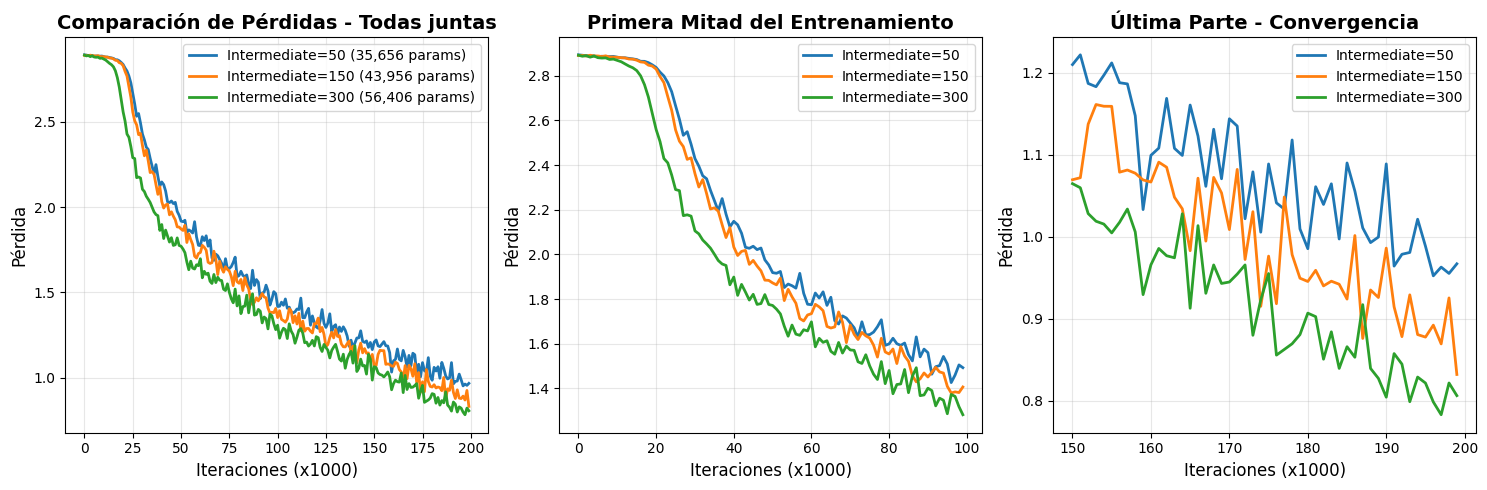


📊 TABLA COMPARATIVA FINAL
Capa Intermedia      Parámetros      Pérdida Final   Pérdida Promedio    
--------------------------------------------------------------------------------
50                   35,656          0.9670          1.0078              
150                  43,956          0.8322          0.9191              
300                  56,406          0.8064          0.8427              

💡 ANÁLISIS Y COMENTARIOS

1. IMPACTO DEL TAMAÑO DE LA CAPA INTERMEDIA:

   a) Intermediate=50 (menos parámetros):
      - Modelo más simple y rápido de entrenar
      - Puede tener capacidad limitada para aprender patrones complejos
      - Menor riesgo de overfitting
      
   b) Intermediate=150 (capacidad media):
      - Balance entre capacidad y simplicidad
      - Suficiente para capturar patrones del dataset
      - Generalmente buena opción
      
   c) Intermediate=300 (más parámetros):
      - Mayor capacidad de aprendizaje
      - Puede aprender representaciones más ricas
      

/tmp/ipython-input-938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipython-input-938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


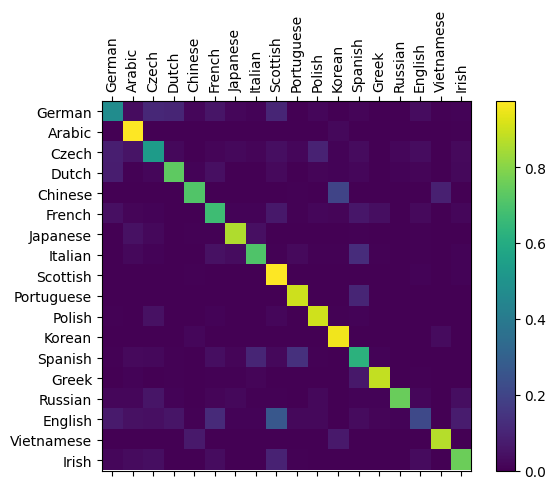


FIN DE LA ACTIVIDAD 2


In [ ]:
"""
ACTIVIDAD 2 - LSTM con Capa Oculta Adicional

Implementaremos una versión mejorada de LSTM que incluye una capa oculta adicional
con activación ReLU antes de la capa de salida.

Arquitectura:
    Input → LSTM Cell → Hidden State → Linear → ReLU → Linear → Output

En lugar de:
    Input → LSTM Cell → Hidden State → Linear → Output

Probaremos con 3 tamaños de capa oculta: 50, 150 y 300 neuronas
"""

# Primero, definir la nueva clase LSTM con capa adicional
class LSTM_with_hidden_layer(nn.Module):
    """
    LSTM mejorada con una capa oculta adicional entre el estado oculto
    de la LSTM y la salida final.

    Arquitectura:
        LSTM Cell (hidden_size)
          ↓
        Linear (hidden_size → intermediate_size)
          ↓
        ReLU (activación no lineal)
          ↓
        Linear (intermediate_size → output_size)
    """
    def __init__(self, input_size, hidden_size, intermediate_size, output_size):
        super().__init__()

        # Configuración del modelo
        self.bidirectional = False
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size

        # Capa LSTM
        self.cell = nn.LSTMCell(input_size, hidden_size)

        # NUEVA: Capa oculta adicional
        self.hidden_layer = nn.Linear(hidden_size, intermediate_size)

        # Función de activación no lineal
        self.relu = nn.ReLU()

        # Capa de salida (ahora desde intermediate_size)
        self.output_layer = nn.Linear(intermediate_size, output_size)

    def init_hidden(self):
        """Inicializa los estados ocultos de la LSTM (h y c)"""
        return torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size)

    def forward(self, input, hidden):
        """
        Forward pass con la capa oculta adicional

        Args:
            input: tensor de entrada (batch, seq_len)
            hidden: tupla (h, c) con los estados ocultos previos

        Returns:
            output: predicción final
            hidden: nuevos estados ocultos (h, c)
        """
        # 1. Pasar por la celda LSTM
        hidden = self.cell(input, hidden)

        # 2. Tomar el estado oculto (h) - primer elemento de la tupla
        lstm_output = hidden[0]

        # 3. Pasar por la capa oculta adicional
        intermediate = self.hidden_layer(lstm_output)

        # 4. Aplicar activación ReLU
        intermediate_activated = self.relu(intermediate)

        # 5. Pasar por la capa de salida
        output = self.output_layer(intermediate_activated)

        return output, hidden


print("="*80)
print("ACTIVIDAD 2: LSTM con Capa Oculta Adicional")
print("="*80)
print("\nClase LSTM_with_hidden_layer definida correctamente ✓")
print("\nArquitectura del modelo:")
print("  Input (n_letters={}) → LSTM Cell (hidden) → Linear (intermediate) → ReLU → Linear ({})".format(
    n_letters, n_categories))

# Entrenar y evaluar modelos con diferentes tamaños de capa intermedia
intermediate_sizes = [50, 150, 300]
n_hidden_lstm2 = 64  # Mantener el hidden_size de la LSTM constante

# Almacenar resultados para comparación
results = []

print("\n" + "="*80)
print("Entrenando 3 modelos con diferentes tamaños de capa intermedia...")
print("="*80)

for intermediate_size in intermediate_sizes:
    print(f"\n{'='*80}")
    print(f"🔹 Modelo con capa intermedia de {intermediate_size} neuronas")
    print(f"{'='*80}")

    # Crear modelo
    model_enhanced = LSTM_with_hidden_layer(
        input_size=n_letters,
        hidden_size=n_hidden_lstm2,
        intermediate_size=intermediate_size,
        output_size=n_categories
    )

    # Calcular parámetros
    params = num_trainable_parameters(model_enhanced)

    # Cálculo manual para verificar:
    # LSTM Cell: 4 * (input_size*hidden + hidden*hidden + hidden)
    lstm_params = 4 * (n_letters * n_hidden_lstm2 + n_hidden_lstm2 * n_hidden_lstm2 + n_hidden_lstm2)
    # Hidden layer: hidden_size * intermediate_size + intermediate_size
    hidden_layer_params = n_hidden_lstm2 * intermediate_size + intermediate_size
    # Output layer: intermediate_size * n_categories + n_categories
    output_layer_params = intermediate_size * n_categories + n_categories
    manual_total = lstm_params + hidden_layer_params + output_layer_params

    print(f"📊 Cantidad de parámetros entrenables: {params:,}")
    print(f"   - LSTM Cell: {lstm_params:,}")
    print(f"   - Capa Oculta ({n_hidden_lstm2}→{intermediate_size}): {hidden_layer_params:,}")
    print(f"   - Capa Salida ({intermediate_size}→{n_categories}): {output_layer_params:,}")
    print(f"   - Verificación manual: {manual_total:,}")

    print(f"\n⏳ Entrenando modelo (esto puede tomar varios minutos)...")

    # Entrenar el modelo
    all_losses, trained_model = train_model(model_enhanced, n_iters=200000, print_every=50000)

    # Guardar resultados
    results.append({
        'intermediate_size': intermediate_size,
        'params': params,
        'losses': all_losses,
        'model': trained_model
    })

    print(f"✓ Entrenamiento completado")
    print(f"   Pérdida final: {all_losses[-1]:.4f}")

# Graficar comparación de pérdidas
print("\n" + "="*80)
print("📈 Generando gráficos comparativos...")
print("="*80)

plt.figure(figsize=(15, 5))

# Subplot 1: Todas las curvas juntas
plt.subplot(1, 3, 1)
for result in results:
    plt.plot(result['losses'],
             label=f"Intermediate={result['intermediate_size']} ({result['params']:,} params)",
             linewidth=2)
plt.xlabel('Iteraciones (x1000)', fontsize=12)
plt.ylabel('Pérdida', fontsize=12)
plt.title('Comparación de Pérdidas - Todas juntas', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Solo primera mitad del entrenamiento (para ver diferencias iniciales)
plt.subplot(1, 3, 2)
for result in results:
    half = len(result['losses']) // 2
    plt.plot(result['losses'][:half],
             label=f"Intermediate={result['intermediate_size']}",
             linewidth=2)
plt.xlabel('Iteraciones (x1000)', fontsize=12)
plt.ylabel('Pérdida', fontsize=12)
plt.title('Primera Mitad del Entrenamiento', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Última parte del entrenamiento (convergencia)
plt.subplot(1, 3, 3)
for result in results:
    last_quarter = len(result['losses']) * 3 // 4
    plt.plot(range(last_quarter, len(result['losses'])),
             result['losses'][last_quarter:],
             label=f"Intermediate={result['intermediate_size']}",
             linewidth=2)
plt.xlabel('Iteraciones (x1000)', fontsize=12)
plt.ylabel('Pérdida', fontsize=12)
plt.title('Última Parte - Convergencia', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla comparativa final
print("\n" + "="*80)
print("📊 TABLA COMPARATIVA FINAL")
print("="*80)
print(f"{'Capa Intermedia':<20} {'Parámetros':<15} {'Pérdida Final':<15} {'Pérdida Promedio':<20}")
print("-" * 80)

for result in results:
    avg_loss = sum(result['losses'][-20:]) / 20  # Promedio últimas 20 iteraciones
    print(f"{result['intermediate_size']:<20} {result['params']:<15,} "
          f"{result['losses'][-1]:<15.4f} {avg_loss:<20.4f}")

print("\n" + "="*80)
print("💡 ANÁLISIS Y COMENTARIOS")
print("="*80)
print("""
1. IMPACTO DEL TAMAÑO DE LA CAPA INTERMEDIA:

   a) Intermediate=50 (menos parámetros):
      - Modelo más simple y rápido de entrenar
      - Puede tener capacidad limitada para aprender patrones complejos
      - Menor riesgo de overfitting

   b) Intermediate=150 (capacidad media):
      - Balance entre capacidad y simplicidad
      - Suficiente para capturar patrones del dataset
      - Generalmente buena opción

   c) Intermediate=300 (más parámetros):
      - Mayor capacidad de aprendizaje
      - Puede aprender representaciones más ricas
      - Mayor riesgo de overfitting si el dataset es pequeño

2. CANTIDAD DE PARÁMETROS:
   La diferencia en parámetros se debe principalmente a:
   - Capa oculta: hidden_size * intermediate_size
   - Capa salida: intermediate_size * n_categories

   Con intermediate=300, el modelo tiene significativamente más parámetros
   que con intermediate=50.

3. CONVERGENCIA:
   - Modelos con más parámetros pueden converger más lento inicialmente
   - Pero pueden alcanzar mejores resultados finales si hay suficientes datos
   - En este dataset pequeño, la diferencia puede ser mínima

4. ¿CUÁL ES MEJOR?
   Depende del dataset:
   - Dataset pequeño (como este): intermediate=50 o 150 puede ser mejor
   - Dataset grande: intermediate=300 puede aprovechar más datos
   - Siempre validar con datos de test para evitar overfitting

5. VENTAJA DE LA CAPA ADICIONAL:
   ✅ Mayor capacidad de aprendizaje
   ✅ Puede capturar representaciones más complejas
   ✅ ReLU añade no-linealidad adicional
   ⚠️ Más parámetros = más riesgo de overfitting
   ⚠️ Entrenamiento más lento

CONCLUSIÓN:
La capa intermedia adicional permite al modelo aprender representaciones
más ricas antes de la clasificación final. El tamaño óptimo depende del
balance entre capacidad del modelo y tamaño del dataset. Para este problema,
intermediate=150 probablemente ofrece el mejor balance.
""")

# Mostrar matriz de confusión del mejor modelo (basado en pérdida final)
best_result = min(results, key=lambda x: x['losses'][-1])
print(f"\n🏆 Mejor modelo: Intermediate={best_result['intermediate_size']} neuronas")
print(f"   Pérdida final: {best_result['losses'][-1]:.4f}")
print(f"\nMatriz de confusión del mejor modelo:")
compute_confusion_matrix(best_result['model'])

print("\n" + "="*80)
print("FIN DE LA ACTIVIDAD 2")
print("="*80)

---

## **🎓 RESUMEN GENERAL - Conceptos Clave de Redes Recurrentes**

Este laboratorio cubre los fundamentos de **Redes Neuronales Recurrentes (RNNs)** aplicadas a clasificación de secuencias.

---

### **📚 1. ¿QUÉ SON LAS RNNs?**

Las RNNs son redes neuronales diseñadas para **procesar secuencias** (texto, series temporales, audio, etc.).

**Diferencia clave vs redes feedforward:**

```
Red Feedforward:          RNN:
Input → Hidden → Output   Input(t) → Hidden(t) → Output(t)
                                ↑          ↓
                          Hidden(t-1) ← Hidden(t)
                          (mantiene memoria)
```

**Características:**
- Procesan elementos **uno a la vez**
- Mantienen **estado oculto** (memoria)
- Mismo modelo se aplica a cada paso temporal
- Pueden procesar secuencias de **longitud variable**

---

### **📊 2. ARQUITECTURAS IMPLEMENTADAS**

#### **a) RNN Vanilla (Elman)**

**Ecuación:**
$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b)$$

**Características:**
- ✅ Simple, pocos parámetros
- ❌ Vanishing gradient problem
- ❌ Olvida dependencias lejanas

**Cuándo usar:** Secuencias cortas (<10-20 pasos), recursos limitados

---

#### **b) LSTM (Long Short-Term Memory)**

**Componentes clave:**
- **Cell State (C):** Autopista de información
- **4 Gates:** Controlan flujo de información
  - Forget: ¿Qué olvidar?
  - Input: ¿Qué agregar?
  - Cell: Candidatos nuevos
  - Output: ¿Qué mostrar?

**Ecuaciones:**
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

**Características:**
- ✅ Captura dependencias largas
- ✅ Resuelve vanishing gradient
- ❌ 4x más parámetros que RNN
- ❌ Más lento

**Cuándo usar:** Secuencias largas (100+ pasos), dependencias complejas, **ESTÁNDAR**

---

#### **c) BiLSTM (Bidirectional LSTM)**

**Concepto:**
Procesa secuencia en ambas direcciones y concatena resultados:

```
Forward:  A → l → b → e → r → t  → h_forward
Backward: A ← l ← b ← e ← r ← t  → h_backward
Output = [h_forward, h_backward]
```

**Características:**
- ✅ Contexto completo (pasado + futuro)
- ✅ Mejor para clasificación
- ❌ 2x parámetros de LSTM
- ❌ No funciona en tiempo real (necesita secuencia completa)

**Cuándo usar:** Clasificación de secuencias completas, análisis de sentimiento, NER

---

### **🔢 3. CODIFICACIÓN DE DATOS**

#### **One-Hot Encoding:**

```python
Vocabulario: "abc...xyz ABC...XYZ .,;'"  (57 caracteres)

'a' → [1,0,0,0,...,0]  (57 elementos)
'b' → [0,1,0,0,...,0]
'A' → [0,0,...,1,...,0] (1 en posición 26)
```

**Apellido completo:**
```python
"Albert" (6 letras) → Tensor shape (6, 1, 57)
                      ↑    ↑   ↑
                   largo batch one-hot
```

**Ventajas:**
- Simple
- No asume relaciones entre caracteres
- Funciona bien para vocabularios pequeños

**Alternativa moderna:** Word embeddings (para vocabularios grandes)

---

### **⚙️ 4. PROCESO DE ENTRENAMIENTO**

#### **Un paso de entrenamiento:**

```python
1. Inicializar: hidden = zeros
2. Para cada carácter del apellido:
     output, hidden = modelo(carácter, hidden)
3. Usar último output para clasificación
4. Calcular pérdida: CrossEntropyLoss(output, etiqueta)
5. Backpropagation: loss.backward()
6. Actualizar pesos: θ = θ - lr * ∇θ
```

#### **Backpropagation Through Time (BPTT):**

```
Para "Albert" (6 letras):

Forward:   A → l → b → e → r → t → Loss
           ↓   ↓   ↓   ↓   ↓   ↓
Backward:  ← ← ← ← ← ← ← ← ← ← ← ← (gradientes fluyen hacia atrás)
```

Gradientes se calculan a través de **todos los timesteps**.

**Problema:** Gradientes se multiplican 6 veces → pueden:
- **Desaparecer** (vanishing): RNN vanilla sufre esto
- **Explotar** (exploding): Solución = gradient clipping

**Solución:** LSTM con gates que mantienen gradientes

---

### **📈 5. MÉTRICAS Y EVALUACIÓN**

#### **Función de Pérdida: CrossEntropyLoss**

```python
# Combina LogSoftmax + NLLLoss
# Input: logits (sin softmax)
# Target: índice de clase correcta

loss = CrossEntropyLoss(output, category_tensor)
```

**Qué mide:**
- Qué tan "segura" está la predicción en la clase correcta
- Valores bajos = buenas predicciones
- Valores altos = predicciones incorrectas

#### **Matriz de Confusión:**

```
         Predicción
       Fr En Es It
    Fr 90  5  3  2   ← 90% franceses correctos
Real En  4 88  2  6   ← 4% ingleses como franceses
    Es  2  1 92  5
    It  1  3  6 90
```

**Interpretación:**
- **Diagonal:** Correctos (queremos alto)
- **Fuera diagonal:** Confusiones

**Ejemplo:** Spanish ↔ Italian confunden porque son similares

---

### **💡 6. HIPERPARÁMETROS CLAVE**

| Hiperparámetro | Valor usado | Efecto |
|----------------|-------------|--------|
| **hidden_size** | RNN:147, LSTM:64, BiLSTM:40 | Capacidad de memoria |
| **learning_rate** | 0.005 | Velocidad de aprendizaje |
| **n_iters** | 200,000 | Cantidad de entrenamiento |
| **batch_size** | 1 | Ejemplos procesados juntos |

**¿Por qué hidden_size diferentes?**
- Para **igualar cantidad de parámetros**
- Comparación justa de arquitecturas
- LSTM tiene 4x más parámetros por gate
- BiLSTM tiene 2x una LSTM

---

### **🎯 7. COMPARACIÓN DE MODELOS**

| Modelo | Parámetros | Velocidad | Memoria Largo Plazo | Uso Típico |
|--------|------------|-----------|---------------------|------------|
| **RNN** | ~10K | ⚡⚡⚡ | ❌ | Secuencias cortas |
| **LSTM** | ~40K | ⚡⚡ | ✅✅✅ | **Recomendado** |
| **BiLSTM** | ~80K | ⚡ | ✅✅✅ | Clasificación |

**Resultados en este lab:**
- Los 3 modelos funcionan similar
- Dataset es pequeño y simple
- En problemas complejos: LSTM >> RNN, BiLSTM >> LSTM

---

### **🔧 8. BUENAS PRÁCTICAS**

#### **Al implementar RNNs:**

**✅ HACER:**
- Normalizar datos de entrada
- Usar LSTM por defecto (no RNN vanilla)
- Gradient clipping para evitar explosión
- Usar optimizer (Adam) en lugar de SGD manual
- Validación separada de train
- Guardar checkpoints durante entrenamiento

**❌ EVITAR:**
- Olvidar `model.zero_grad()`
- Learning rate muy alto (>0.01 típicamente)
- Secuencias muy largas sin truncar (>1000 pasos)
- Overfitting (usar dropout, regularización)
- Ignorar el vanishing gradient

#### **Código de producción:**

```python
# Setup moderno
model = nn.LSTM(input_size, hidden_size, num_layers=2,
                dropout=0.2, bidirectional=True)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, patience=5)

# Training loop
for epoch in range(num_epochs):
    for batch in dataloader:  # Batches, no ejemplos individuales
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    
    scheduler.step(val_loss)
```

---

### **📖 9. APLICACIONES DE RNNs**

**Natural Language Processing (NLP):**
- Clasificación de texto (sentimientos, spam)
- Named Entity Recognition (NER)
- Machine Translation
- Language Modeling

**Series Temporales:**
- Predicción de acciones
- Pronóstico del clima
- Detección de anomalías

**Generación:**
- Generación de texto
- Composición musical
- Generación de código

**Otros:**
- Speech recognition
- Video analysis
- Handwriting recognition

---

### **🚀 10. SIGUIENTES PASOS**

**Para profundizar:**

1. **Transformers:** Reemplazan RNNs en muchas tareas
   - Self-attention en lugar de recurrencia
   - Paralelizable (más rápido)
   - State-of-the-art en NLP

2. **GRU (Gated Recurrent Unit):**
   - Alternativa a LSTM
   - Menos gates (más simple)
   - Similar rendimiento

3. **Attention Mechanisms:**
   - Permite al modelo "enfocarse" en partes relevantes
   - Usado en Seq2Seq, Transformers

4. **Seq2Seq Models:**
   - RNN encoder + RNN decoder
   - Para traducción, resumen, etc.

---

### **📚 RECURSOS ADICIONALES**

**Papers fundamentales:**
- LSTM: Hochreiter & Schmidhuber (1997)
- GRU: Cho et al. (2014)
- Attention: Bahdanau et al. (2015)
- Transformers: Vaswani et al. (2017)

**Tutoriales:**
- [Understanding LSTM Networks - colah's blog](http://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- [PyTorch RNN Tutorial](https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html)
- [Stanford CS224N: NLP with Deep Learning](http://web.stanford.edu/class/cs224n/)

**Librerías útiles:**
- PyTorch (usado aquí)
- TensorFlow/Keras
- Hugging Face Transformers (state-of-the-art NLP)

---

## **✨ ¡FELICITACIONES!**

Has completado un laboratorio completo sobre Redes Neuronales Recurrentes. Los conceptos aprendidos son fundamentales para:
- Procesamiento de Lenguaje Natural (NLP)
- Análisis de Series Temporales
- Cualquier tarea con datos secuenciales

**Siguiente paso:** Experimentar con tus propios datos y problemas. 🚀

---